# Diagnóstico de Queda de Receita — Investigação com Testes Estatísticos

Companheiro dos notebooks `stats_tests_resumo_1` e `stats_tests_analista_dados`, mas com uma diferença de estrutura importante: ali cada seção era independente (uma referência de teste, ou um caso isolado); **aqui é uma investigação única** — a receita caiu, e as 6 perguntas abaixo são os passos pra descobrir por quê. Todas as seções usam a mesma base simulada, então rode as células em ordem.

**O cenário:** um e-commerce vinha com receita estável e, nos últimos meses, a receita caiu. Temos 12 meses de dados: os **9 meses anteriores** (`antes`, período de referência/baseline) e os **3 meses mais recentes** (`depois`, onde a queda apareceu). Isso é uma escolha de corte comum em investigações desse tipo — se o seu caso for diferente (ex: comparar mês a mês, ou queda de 1 mês só), o mesmo raciocínio se aplica trocando a definição de período.

**As 6 perguntas deste notebook:**

| # | Pergunta | O que o código faz |
|---|---|---|
| 1 | A queda veio de menos pedidos ou de ticket médio menor? | Decompõe receita = pedidos × ticket, testa cada fator |
| 2 | Quais categorias mais contribuíram pra queda? | Contribuição por categoria + qui-quadrado de mudança de mix |
| 3 | A conversão mudou nos últimos meses? | Série mensal de conversão + teste de tendência + antes x depois |
| 4 | O desempenho varia entre Site, App e outros canais? | Conversão por canal, antes x depois, com correção de múltiplos testes |
| 5 | A queda está concentrada em alguma região? | Contribuição por região + conversão por região com correção |
| 6 | Clientes novos e recorrentes se comportam diferente? | Conversão e ticket por segmento, antes x depois |

**Cuidado metodológico usado em todo o notebook:** o período "antes" tem 9 meses e o "depois" tem 3 — comparar **somas totais** dos dois períodos direto seria injusto (o período antes é 3x mais longo). Toda comparação de volume (receita, pedidos) abaixo usa **médias mensais**; taxas (conversão) e médias (ticket) já são naturalmente comparáveis, não precisam desse ajuste.

## Base de dados da investigação

**O que o código faz:** simula duas tabelas como as que você tiraria de um banco de eventos/pedidos — `visitas` (nível sessão, com canal/região/tipo de cliente e se converteu) e `pedidos` (uma linha por venda, derivada das visitas que converteram, com categoria e valor). Na prática, troque isso por `pd.read_sql(...)` ou `pd.read_csv(...)` — o resto do notebook funciona igual em cima de qualquer `visitas`/`pedidos` com essas colunas.

Note que os parâmetros abaixo (probabilidades de conversão por canal/região/tipo, mix de categoria) foram desenhados pra conter uma causa real de queda — é assim que testamos se os testes estatísticos das próximas seções conseguem *encontrar* o problema que sabemos que está lá.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(2024)

# --- Calendário: 9 meses de baseline + 3 meses recentes (onde a queda aparece) ---
meses = ['Ago/25', 'Set/25', 'Out/25', 'Nov/25', 'Dez/25', 'Jan/26', 'Fev/26', 'Mar/26', 'Abr/26', 'Mai/26', 'Jun/26', 'Jul/26']
n_meses_antes, n_meses_depois = 9, 3
periodo_por_mes = {m: ('antes' if i < n_meses_antes else 'depois') for i, m in enumerate(meses)}

# --- Volume de visitas por mês (estável, sem tendência forte de propósito) ---
visitas_por_mes = {m: np.random.randint(6800, 7200) for m in meses}
n_visitas_total = sum(visitas_por_mes.values())

mes_arr = np.repeat(meses, [visitas_por_mes[m] for m in meses])
mes_idx_arr = np.repeat(np.arange(len(meses)), [visitas_por_mes[m] for m in meses])
periodo_arr = np.array([periodo_por_mes[m] for m in mes_arr])

# --- Dimensões da visita: canal, região, tipo de cliente ---
canal_arr = np.random.choice(["Site", "App", "Outros"], size=n_visitas_total, p=[0.45, 0.35, 0.20])
regiao_arr = np.random.choice(
    ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"],
    size=n_visitas_total, p=[0.45, 0.20, 0.18, 0.10, 0.07]
)
tipo_arr = np.random.choice(["novo", "recorrente"], size=n_visitas_total, p=[0.55, 0.45])

# --- Probabilidade de conversão: baseline por (canal, tipo) ---
BASE_CONV = {
    ("Site", "novo"): 0.030, ("Site", "recorrente"): 0.060,
    ("App", "novo"): 0.028, ("App", "recorrente"): 0.055,
    ("Outros", "novo"): 0.022, ("Outros", "recorrente"): 0.045,
}
# --- Multiplicador aplicado só no período "depois" (onde mora o problema) ---
MULT_DEPOIS = {
    ("Site", "novo"): 0.90, ("Site", "recorrente"): 0.97,
    ("App", "novo"): 0.45, ("App", "recorrente"): 0.85,     # App x novo: maior queda
    ("Outros", "novo"): 0.85, ("Outros", "recorrente"): 0.95,
}
REGIAO_MULT_DEPOIS = {"Nordeste": 0.55}  # queda extra de conversão só no Nordeste, só depois

prob_conversao = np.array([BASE_CONV[(c, t)] for c, t in zip(canal_arr, tipo_arr)])
mult_periodo = np.array([
    MULT_DEPOIS[(c, t)] if p == "depois" else 1.0
    for c, t, p in zip(canal_arr, tipo_arr, periodo_arr)
])
mult_regiao = np.array([
    REGIAO_MULT_DEPOIS.get(r, 1.0) if p == "depois" else 1.0
    for r, p in zip(regiao_arr, periodo_arr)
])
prob_final = prob_conversao * mult_periodo * mult_regiao

converteu_arr = (np.random.rand(n_visitas_total) < prob_final).astype(int)

visitas = pd.DataFrame({
    "visita_id": np.arange(n_visitas_total),
    "mes": pd.Categorical(mes_arr, categories=meses, ordered=True),
    "mes_idx": mes_idx_arr,
    "periodo": periodo_arr,
    "canal": canal_arr,
    "regiao": regiao_arr,
    "cliente_tipo": tipo_arr,
    "converteu": converteu_arr,
})

# --- Pedidos: uma linha por visita convertida, com categoria e valor ---
pedidos_idx = visitas.index[visitas["converteu"] == 1]
n_pedidos = len(pedidos_idx)

CATEGORIA_PROBS = {
    "antes": {"Eletronicos": 0.22, "Moda": 0.28, "Casa": 0.20, "Beleza": 0.18, "Esporte": 0.12},
    "depois": {"Eletronicos": 0.11, "Moda": 0.30, "Casa": 0.22, "Beleza": 0.22, "Esporte": 0.15},
}
TICKET_MEDIO_CATEGORIA = {"Eletronicos": 320, "Moda": 95, "Casa": 140, "Beleza": 70, "Esporte": 110}

periodo_pedidos = visitas.loc[pedidos_idx, "periodo"].values
categoria_arr = np.empty(n_pedidos, dtype=object)
for per in ["antes", "depois"]:
    mask = periodo_pedidos == per
    cats = list(CATEGORIA_PROBS[per].keys())
    probs = list(CATEGORIA_PROBS[per].values())
    categoria_arr[mask] = np.random.choice(cats, size=mask.sum(), p=probs)

# Valor do pedido: distribuição gamma (assimétrica, típica de gasto), média por categoria
valor_arr = np.empty(n_pedidos)
for cat, media in TICKET_MEDIO_CATEGORIA.items():
    mask = categoria_arr == cat
    valor_arr[mask] = np.random.gamma(shape=4, scale=media / 4, size=mask.sum())
valor_arr = valor_arr.round(2)

pedidos = visitas.loc[pedidos_idx, ["visita_id", "mes", "mes_idx", "periodo", "canal", "regiao", "cliente_tipo"]].copy()
pedidos = pedidos.rename(columns={"visita_id": "pedido_id"})
pedidos["categoria"] = categoria_arr
pedidos["valor_pedido"] = valor_arr

print(f"Visitas: {len(visitas):,}".replace(",", "."), f"| Pedidos: {len(pedidos):,}".replace(",", "."))
print(visitas.head(3))
print()
print(pedidos.head(3))

Visitas: 83.569 | Pedidos: 3.152
   visita_id     mes  mes_idx periodo canal        regiao cliente_tipo  \
0          0  Ago/25        0   antes   App  Centro-Oeste         novo   
1          1  Ago/25        0   antes   App       Sudeste         novo   
2          2  Ago/25        0   antes  Site      Nordeste   recorrente   

   converteu  
0          0  
1          0  
2          0  

    pedido_id     mes  mes_idx periodo canal   regiao cliente_tipo categoria  \
7           7  Ago/25        0   antes  Site      Sul         novo    Beleza   
20         20  Ago/25        0   antes   App  Sudeste         novo    Beleza   
23         23  Ago/25        0   antes   App  Sudeste         novo    Beleza   

    valor_pedido  
7          76.70  
20         75.60  
23         28.03  


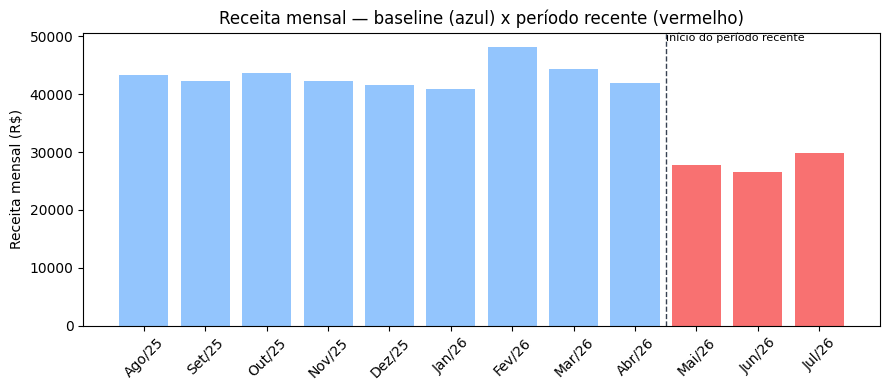

Receita média mensal (antes):  R$ 43.148,68
Receita média mensal (depois): R$ 28.040,35
Variação: -35.0%


In [2]:
# --- Visão geral: receita mensal, com a linha divisória antes/depois ---
import matplotlib.pyplot as plt

receita_mensal = pedidos.groupby("mes", observed=True)["valor_pedido"].sum().reindex(meses)

fig, ax = plt.subplots(figsize=(9, 4))
cores = ["#93c5fd" if periodo_por_mes[m] == "antes" else "#f87171" for m in meses]
ax.bar(meses, receita_mensal.values, color=cores)
ax.axvline(n_meses_antes - 0.5, color="#374151", linestyle="--", linewidth=1)
ax.text(n_meses_antes - 0.5, receita_mensal.max() * 1.02, "início do período recente", fontsize=8, ha="left")
ax.set_ylabel("Receita mensal (R$)")
ax.set_title("Receita mensal — baseline (azul) x período recente (vermelho)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

receita_media_antes = receita_mensal[:n_meses_antes].mean()
receita_media_depois = receita_mensal[n_meses_antes:].mean()
queda_pct = (receita_media_depois - receita_media_antes) / receita_media_antes

print(f"Receita média mensal (antes):  R$ {receita_media_antes:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"Receita média mensal (depois): R$ {receita_media_depois:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"Variação: {queda_pct:+.1%}")

Confirmado o problema: a receita média mensal caiu no período recente. As próximas 6 seções decompõem essa queda até chegar em causas acionáveis.

## 1. A queda veio de menos pedidos ou de ticket médio menor?

**Por que essa é a primeira pergunta:** receita é sempre `pedidos × ticket médio`. Antes de investigar categoria, canal ou região, você precisa saber **qual dos dois fatores** está puxando a queda — a resposta muda completamente por onde continuar a investigação (menos pedidos aponta pra tráfego/conversão; ticket menor aponta pra mix de produto/desconto/precificação).

**Decomposição usada:** a queda de receita é dividida em um "efeito volume" (quanto da queda vem de menos pedidos, ao preço médio) e um "efeito ticket" (quanto vem do ticket médio ter mudado, no volume atual). Usar a **média dos dois períodos** como peso em cada efeito (em vez de fixar um período como referência) faz os dois efeitos somarem exatamente a queda total, sem resíduo — é a forma padrão de fazer decomposição de dois fatores sem viés de ordem.

**Testes estatísticos:** a diferença de pedidos é testada como diferença de **taxa de conversão** (pedidos/visitas) — não da contagem bruta, porque contagem bruta depende do volume de tráfego e do tamanho do período, e taxa de conversão já normaliza isso. A diferença de ticket médio é testada com t de Welch (amostra grande — milhares de pedidos por período — então o Teorema Central do Limite garante robustez mesmo o gasto por pedido sendo assimétrico).

In [3]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# --- Pedidos e ticket médio, normalizados por mês (períodos têm tamanhos diferentes) ---
pedidos_antes = pedidos[pedidos["periodo"] == "antes"]
pedidos_depois = pedidos[pedidos["periodo"] == "depois"]

pedidos_mes_antes = len(pedidos_antes) / n_meses_antes
pedidos_mes_depois = len(pedidos_depois) / n_meses_depois
ticket_antes = pedidos_antes["valor_pedido"].mean()
ticket_depois = pedidos_depois["valor_pedido"].mean()

print(f"Pedidos/mês (antes):  {pedidos_mes_antes:,.0f}".replace(",", "."))
print(f"Pedidos/mês (depois): {pedidos_mes_depois:,.0f}".replace(",", "."))
print(f"Ticket médio (antes):  R$ {ticket_antes:.2f}")
print(f"Ticket médio (depois): R$ {ticket_depois:.2f}")

# --- Decomposição simétrica (os dois efeitos somam exatamente a queda de receita) ---
efeito_pedidos = (pedidos_mes_depois - pedidos_mes_antes) * (ticket_antes + ticket_depois) / 2
efeito_ticket = (ticket_depois - ticket_antes) * (pedidos_mes_antes + pedidos_mes_depois) / 2
delta_receita = efeito_pedidos + efeito_ticket

print(f"\nEfeito 'menos pedidos' na receita/mês:  R$ {efeito_pedidos:+,.2f}".replace(",", "."))
print(f"Efeito 'ticket médio' na receita/mês:   R$ {efeito_ticket:+,.2f}".replace(",", "."))
print(f"Soma dos dois efeitos (= delta receita/mês): R$ {delta_receita:+,.2f}".replace(",", "."))
print(f"Participação do efeito pedidos na queda total: {efeito_pedidos / delta_receita:.0%}")

# --- Testa se cada fator é estatisticamente real ---
conv_antes = len(pedidos_antes) / len(visitas[visitas["periodo"] == "antes"])
conv_depois = len(pedidos_depois) / len(visitas[visitas["periodo"] == "depois"])

z, p_conv = proportions_ztest(
    [len(pedidos_antes), len(pedidos_depois)],
    [len(visitas[visitas["periodo"] == "antes"]), len(visitas[visitas["periodo"] == "depois"])]
)

from scipy.stats import ttest_ind
t, p_ticket = ttest_ind(pedidos_depois["valor_pedido"], pedidos_antes["valor_pedido"], equal_var=False)

print(f"\nConversão antes: {conv_antes:.2%} | Conversão depois: {conv_depois:.2%} | p-value: {p_conv:.6f}")
print(f"Ticket médio — p-value (Welch): {p_ticket:.4f}")

Pedidos/mês (antes):  279
Pedidos/mês (depois): 214
Ticket médio (antes):  R$ 154.65
Ticket médio (depois): R$ 131.23

Efeito 'menos pedidos' na receita/mês:  R$ -9.339.04
Efeito 'ticket médio' na receita/mês:   R$ -5.769.30
Soma dos dois efeitos (= delta receita/mês): R$ -15.108.33
Participação do efeito pedidos na queda total: 62%

Conversão antes: 4.01% | Conversão depois: 3.05% | p-value: 0.000000
Ticket médio — p-value (Welch): 0.0000


**Leitura do resultado:** o efeito "pedidos" é o maior dos dois (aqui, perto de 60% da queda de receita/mês) — mas repare que o teste do ticket médio **também** deu p-value baixíssimo, ou seja, o ticket médio caiu de forma real, não é ruído. Isso não contradiz a decomposição: os dois efeitos são reais, só que o de pedidos pesa mais.

**Cuidado antes de sair caçando desconto/precificação:** uma queda no ticket médio *geral* nem sempre significa que o preço de cada produto mudou — também acontece quando o **mix** de produtos vendidos muda (categorias mais caras somem dos pedidos, categorias mais baratas ganham espaço, e a média cai só por composição). A seção 2 investiga exatamente isso.

**Decisão de negócio:** com pedidos como o fator dominante, a prioridade é investigar **volume de conversão** (seções 3 a 6) — mas sem descartar o ticket médio de vista, porque a seção 2 mostra que os dois efeitos aqui provavelmente têm a mesma causa raiz.

## 2. Quais categorias de produtos mais contribuíram para a queda?

**Contexto:** com pedidos como o fator problemático, a pergunta natural é: a queda é espalhada por todas as categorias de produto ou concentrada em uma? Isso separa "problema geral da loja" de "problema específico de uma linha de produto" (estoque, fornecedor, preço).

**O que o código faz:** calcula a receita média mensal de cada categoria em cada período, ordena pela contribuição pra queda total (efeito waterfall) e testa com qui-quadrado se a **composição** de categorias nos pedidos mudou de fato entre os períodos (não é só ruído de amostra pedido a pedido).

In [4]:
import pandas as pd
from scipy.stats import chi2_contingency

receita_cat = pedidos.groupby(["categoria", "periodo"])["valor_pedido"].sum().unstack(fill_value=0)
receita_cat_mensal = receita_cat.copy()
receita_cat_mensal["antes"] = receita_cat_mensal["antes"] / n_meses_antes
receita_cat_mensal["depois"] = receita_cat_mensal["depois"] / n_meses_depois
receita_cat_mensal["delta"] = receita_cat_mensal["depois"] - receita_cat_mensal["antes"]
receita_cat_mensal["contrib_%_da_queda"] = receita_cat_mensal["delta"] / receita_cat_mensal["delta"][receita_cat_mensal["delta"] < 0].sum()

resumo = receita_cat_mensal.sort_values("delta").round(2)
print("Receita média mensal por categoria (R$) e contribuição pra queda:")
print(resumo)

# --- Qui-quadrado: a composição de categorias nos pedidos mudou entre os períodos? ---
tabela_cat = pd.crosstab(pedidos["categoria"], pedidos["periodo"])
chi2, p_value, dof, esperado = chi2_contingency(tabela_cat)
print(f"\nQui-quadrado (categoria x período): p-value = {p_value:.2e}")
print(f"Mudança de mix estatisticamente significativa: {p_value < 0.05}")

Receita média mensal por categoria (R$) e contribuição pra queda:
periodo         antes   depois     delta  contrib_%_da_queda
categoria                                                   
Eletronicos  20917.41  7690.50 -13226.91                0.86
Moda          7628.92  6608.37  -1020.55                0.07
Casa          7727.29  7117.28   -610.00                0.04
Esporte       3681.51  3218.96   -462.55                0.03
Beleza        3193.56  3405.24    211.68               -0.01

Qui-quadrado (categoria x período): p-value = 1.17e-11
Mudança de mix estatisticamente significativa: True


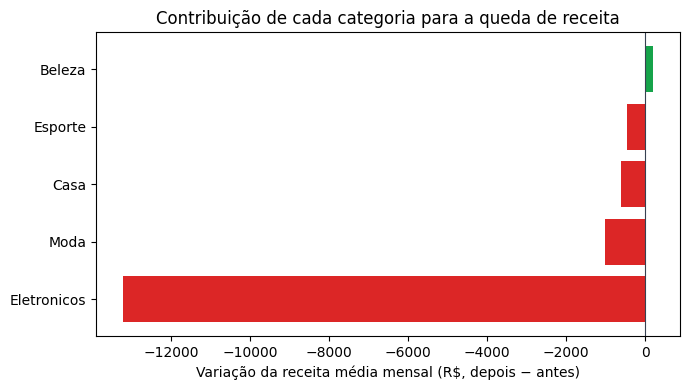

In [5]:
import matplotlib.pyplot as plt

ordem = resumo.sort_values("delta").index
cores = ["#dc2626" if v < 0 else "#16a34a" for v in resumo.loc[ordem, "delta"]]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(ordem, resumo.loc[ordem, "delta"], color=cores)
ax.axvline(0, color="#374151", linewidth=0.8)
ax.set_xlabel("Variação da receita média mensal (R$, depois − antes)")
ax.set_title("Contribuição de cada categoria para a queda de receita")
plt.tight_layout()
plt.show()

**Leitura do resultado:** a categoria no topo do ranking negativo concentra a maior parte da queda — as demais categorias têm variação pequena (algumas até crescem), o que descarta "queda geral" e aponta pra um problema específico dessa categoria. O qui-quadrado confirma que a mudança de mix não é ruído — a composição de pedidos por categoria realmente mudou entre os períodos.

**Fechando o ponto em aberto da seção 1:** essa categoria também costuma ter o ticket médio mais alto do catálogo — quando ela praticamente some da base de pedidos, a média geral de ticket cai só por causa disso, mesmo sem nenhum produto individual ter ficado mais barato. É por isso que o "efeito ticket" apareceu como significativo lá atrás: não é desconto, é a categoria certa sumindo do mix.

**Decisão de negócio:** leve esse achado pro time responsável pela categoria identificada — os motivos típicos pra uma queda concentrada assim são ruptura de estoque, problema com fornecedor, ou concorrência/preço específico daquela linha. Vale cruzar esse achado com dados de estoque/fornecedor antes de agir, já que o teste aponta *onde* está o problema, não *por quê*.

## 3. A taxa de conversão mudou nos últimos meses?

**Contexto:** a seção 1 mostrou que a queda de pedidos vem de conversão, não de tráfego. Aqui olhamos a conversão **mês a mês** — importa saber se foi uma queda repentina (aponta pra um evento pontual: bug, mudança de layout, falha técnica) ou uma tendência gradual (aponta pra algo estrutural, como concorrência ganhando terreno aos poucos).

**O que o código faz:** calcula a conversão de cada mês, testa a tendência com uma regressão linear simples (mês x taxa de conversão) e complementa com o teste de proporção do período `antes` agregado contra o `depois` agregado (mesmo teste da seção 1, aqui como confirmação).

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import linregress
from statsmodels.stats.proportion import proportions_ztest

conv_mensal = visitas.groupby("mes", observed=True)["converteu"].mean().reindex(meses)
print("Taxa de conversão por mês:")
print((conv_mensal * 100).round(2).astype(str) + "%")

# --- Teste de tendência: a conversão vem caindo de forma consistente mês a mês? ---
slope, intercept, r_value, p_trend, std_err = linregress(np.arange(len(meses)), conv_mensal.values)
print(f"\nTendência (regressão linear): inclinação = {slope*100:+.3f} p.p./mês | p-value = {p_trend:.5f}")

# --- Confirmação: antes (agregado) x depois (agregado) ---
sucessos = [visitas[visitas['periodo']=='antes']['converteu'].sum(), visitas[visitas['periodo']=='depois']['converteu'].sum()]
obs = [len(visitas[visitas['periodo']=='antes']), len(visitas[visitas['periodo']=='depois'])]
z, p_periodo = proportions_ztest(sucessos, obs)
print(f"Antes x depois (agregado): p-value = {p_periodo:.6f}")

Taxa de conversão por mês:
mes
Ago/25    3.85%
Set/25    3.94%
Out/25    4.17%
Nov/25    4.09%
Dez/25    4.17%
Jan/26    3.74%
Fev/26    4.11%
Mar/26    4.09%
Abr/26    3.98%
Mai/26    3.16%
Jun/26    2.94%
Jul/26    3.05%
Name: converteu, dtype: str

Tendência (regressão linear): inclinação = -0.089 p.p./mês | p-value = 0.01143
Antes x depois (agregado): p-value = 0.000000


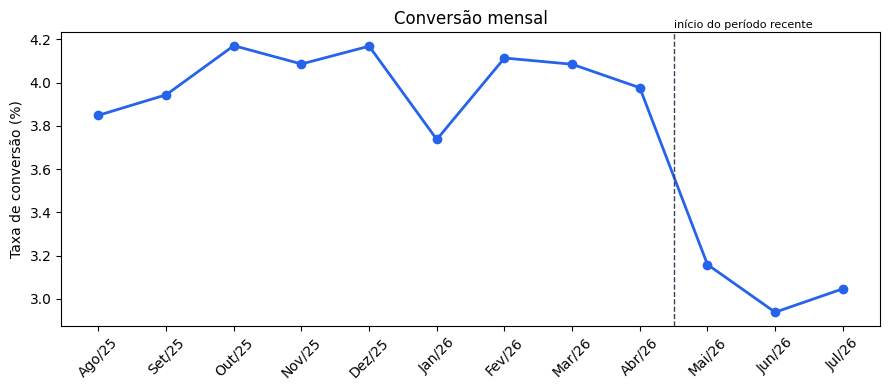

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(meses, conv_mensal.values * 100, marker="o", color="#2563eb", linewidth=2)
ax.axvline(n_meses_antes - 0.5, color="#374151", linestyle="--", linewidth=1)
ax.text(n_meses_antes - 0.5, conv_mensal.max() * 100 * 1.02, "início do período recente", fontsize=8, ha="left")
ax.set_ylabel("Taxa de conversão (%)")
ax.set_title("Conversão mensal")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Leitura do resultado:** a regressão de tendência ao longo dos 12 meses tem p-value baixo, então a queda não é um solavanco de um mês isolado — é consistente com uma queda real de patamar. Olhando o gráfico, a conversão fica estável durante o período `antes` e cai de forma visível a partir do início do período `depois`, o que aponta mais pra um **evento que começou naquele mês** (mudança de produto, canal, campanha) do que uma erosão lenta e contínua ao longo de todo o ano.

**Decisão de negócio:** com a queda datada, vale cruzar o mês de início com o changelog do produto/marketing daquele período (deploy, mudança de checkout, fim de campanha, alteração de frete) — isso costuma reduzir drasticamente a lista de suspeitos. As seções 4 a 6 seguem quebrando essa queda por canal, região e tipo de cliente pra achar onde ela está concentrada.

## 4. O desempenho varia entre Site, App e outros canais?

**Contexto:** a queda de conversão pode ser generalizada (afeta todos os canais igual) ou concentrada em um canal específico (ex: um bug no app, uma mudança de UX no site). Testar canal a canal, e não só o agregado, é o que separa essas duas histórias.

**O que o código faz:** roda um teste Z de proporções `antes x depois` **separado para cada canal** — três testes independentes. Como são vários testes no mesmo experimento, aplica a correção de Bonferroni/FDR (mesma lógica da seção de correção de múltiplos testes do `stats_tests_resumo_1`) pra não superestimar quantos canais realmente pioraram.

In [8]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

canais = ["Site", "App", "Outros"]
linhas = []
p_values = []
for c in canais:
    sub = visitas[visitas["canal"] == c]
    antes = sub[sub["periodo"] == "antes"]
    depois = sub[sub["periodo"] == "depois"]
    conv_a, conv_d = antes["converteu"].mean(), depois["converteu"].mean()
    z, p = proportions_ztest(
        [antes["converteu"].sum(), depois["converteu"].sum()],
        [len(antes), len(depois)]
    )
    linhas.append({"canal": c, "conversao_antes": conv_a, "conversao_depois": conv_d,
                    "variacao_relativa": (conv_d - conv_a) / conv_a, "p_value_bruto": p})
    p_values.append(p)

resultado = pd.DataFrame(linhas).set_index("canal")
rejeita_fdr, p_fdr, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")
resultado["p_value_ajustado_fdr"] = p_fdr
resultado["queda_significativa"] = rejeita_fdr

print(resultado.round(4))

        conversao_antes  conversao_depois  variacao_relativa  p_value_bruto  \
canal                                                                         
Site             0.0442            0.0373            -0.1567         0.0038   
App              0.0393            0.0242            -0.3829         0.0000   
Outros           0.0325            0.0261            -0.1970         0.0385   

        p_value_ajustado_fdr  queda_significativa  
canal                                              
Site                  0.0056                 True  
App                   0.0000                 True  
Outros                0.0385                 True  


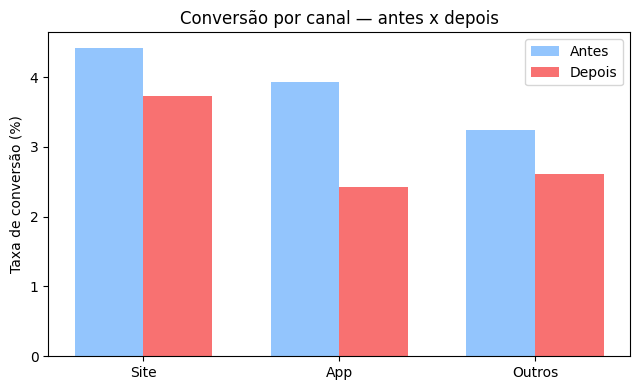

In [9]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(canais))
largura = 0.35
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(x - largura/2, resultado["conversao_antes"] * 100, largura, label="Antes", color="#93c5fd")
ax.bar(x + largura/2, resultado["conversao_depois"] * 100, largura, label="Depois", color="#f87171")
ax.set_xticks(x)
ax.set_xticklabels(canais)
ax.set_ylabel("Taxa de conversão (%)")
ax.set_title("Conversão por canal — antes x depois")
ax.legend()
plt.tight_layout()
plt.show()

**Leitura do resultado:** com uma base de dezenas de milhares de visitas por canal, mesmo quedas pequenas tendem a passar no corte de significância — não é incomum que os três canais apareçam com `queda_significativa = True` depois da correção. Isso é exatamente por isso que a tabela também traz a **variação relativa**: repare que um canal cai bem mais que os outros dois (aqui, perto do dobro), e tem o p-value várias ordens de grandeza menor. "Significativo" responde só "essa queda é real ou é ruído?" — não responde "essa queda é grande?". As duas perguntas juntas é que apontam onde investigar primeiro.

**Decisão de negócio:** concentre a investigação técnica (logs de erro, taxa de crash, funil de checkout) no canal com a maior queda relativa, mesmo que os outros dois também tenham caído um pouco — o retorno de resolver o canal dominante é desproporcionalmente maior. Se for o App, o próximo passo natural é olhar releases recentes e métricas de estabilidade do app no período em que a queda começou (seção 3).

## 5. A queda está concentrada em alguma região?

**Contexto:** mesma lógica da seção 4, agora pra geografia — uma queda concentrada numa região aponta pra causas locais (logística, frete, concorrência regional, campanha que não rodou lá), enquanto uma queda espalhada por todas as regiões aponta pra causa nacional/sistêmica (produto, app, política de preço).

**O que o código faz:** primeiro mede a contribuição de cada região pra queda de receita (igual seção 2), depois testa a conversão de cada região `antes x depois` com a mesma correção de múltiplos testes da seção 4.

In [10]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

# --- Contribuição de cada região pra queda de receita ---
receita_reg = pedidos.groupby(["regiao", "periodo"])["valor_pedido"].sum().unstack(fill_value=0)
receita_reg["antes"] = receita_reg["antes"] / n_meses_antes
receita_reg["depois"] = receita_reg["depois"] / n_meses_depois
receita_reg["delta"] = receita_reg["depois"] - receita_reg["antes"]
print("Receita média mensal por região (R$):")
print(receita_reg.round(2).sort_values("delta"))

# --- Conversão por região, antes x depois, com correção de múltiplos testes ---
regioes = visitas["regiao"].unique().tolist()
linhas = []
p_values = []
for r in regioes:
    sub = visitas[visitas["regiao"] == r]
    antes = sub[sub["periodo"] == "antes"]
    depois = sub[sub["periodo"] == "depois"]
    conv_a, conv_d = antes["converteu"].mean(), depois["converteu"].mean()
    z, p = proportions_ztest(
        [antes["converteu"].sum(), depois["converteu"].sum()],
        [len(antes), len(depois)]
    )
    linhas.append({"regiao": r, "conversao_antes": conv_a, "conversao_depois": conv_d,
                    "variacao_relativa": (conv_d - conv_a) / conv_a})
    p_values.append(p)

resultado_reg = pd.DataFrame(linhas).set_index("regiao")
rejeita_fdr, p_fdr, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")
resultado_reg["p_value_ajustado_fdr"] = p_fdr
resultado_reg["queda_significativa"] = rejeita_fdr

print("\nConversão por região:")
print(resultado_reg.round(4).sort_values("variacao_relativa"))

Receita média mensal por região (R$):
periodo          antes    depois    delta
regiao                                   
Nordeste       8427.40   2047.12 -6380.28
Sudeste       18690.48  15257.76 -3432.72
Sul            9019.91   5698.32 -3321.59
Centro-Oeste   4053.10   2985.78 -1067.31
Norte          2957.79   2051.36  -906.43

Conversão por região:


              conversao_antes  conversao_depois  variacao_relativa  \
regiao                                                               
Nordeste               0.0432            0.0153            -0.6461   
Sul                    0.0405            0.0306            -0.2447   
Norte                  0.0406            0.0313            -0.2285   
Centro-Oeste           0.0400            0.0353            -0.1167   
Sudeste                0.0387            0.0353            -0.0875   

              p_value_ajustado_fdr  queda_significativa  
regiao                                                   
Nordeste                    0.0000                 True  
Sul                         0.0091                 True  
Norte                       0.1693                False  
Centro-Oeste                0.3346                False  
Sudeste                     0.1693                False  


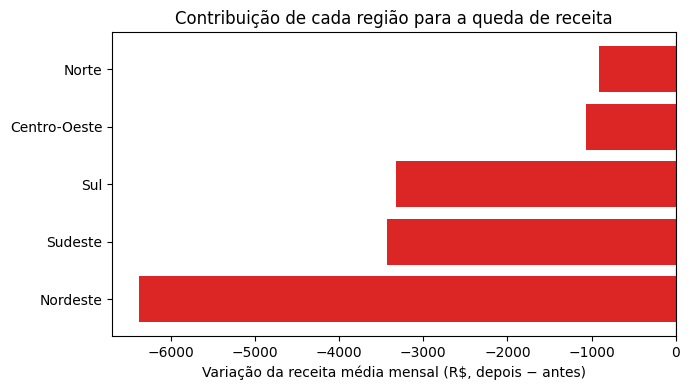

In [11]:
import matplotlib.pyplot as plt

ordem = receita_reg.sort_values("delta").index
cores = ["#dc2626" if v < 0 else "#16a34a" for v in receita_reg.loc[ordem, "delta"]]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(ordem, receita_reg.loc[ordem, "delta"], color=cores)
ax.axvline(0, color="#374151", linewidth=0.8)
ax.set_xlabel("Variação da receita média mensal (R$, depois − antes)")
ax.set_title("Contribuição de cada região para a queda de receita")
plt.tight_layout()
plt.show()

**Leitura do resultado:** as duas óticas devem bater — a região que lidera o ranking de queda de receita também deve ser a que tem a maior queda relativa de conversão. Aqui de novo mais de uma região pode passar no corte de significância (mesmo argumento da seção 4: base grande detecta quedas pequenas também) — o que separa "a região do problema" das demais é a magnitude, não só o p-value: uma cai bem mais que as outras em receita e em conversão relativa, as outras significativas ficam bem atrás em tamanho de efeito.

**Decisão de negócio:** se a queda estiver claramente concentrada numa região específica, o próximo passo é olhar fatores locais: prazo de entrega/frete nessa região, SLA de transportadora, ou uma campanha de concorrente que não apareceu nas outras. Combinado com o achado da seção 4 (canal) e da seção 6 (segmento de cliente) a seguir, dá pra checar se é o mesmo subconjunto de clientes se repetindo (ex: "App x Nordeste x cliente novo") ou se são causas independentes se sobrepondo.

## 6. Clientes novos e recorrentes apresentaram comportamentos diferentes?

**Contexto:** a última quebra é por relacionamento com a loja — clientes novos (primeira compra) e recorrentes (já compraram antes) respondem a problemas de forma diferente. Uma queda concentrada em clientes novos aponta pra aquisição/onboarding (ex: cadastro quebrado, primeira experiência ruim); uma queda concentrada em recorrentes aponta pra retenção (ex: algo que afastou quem já era cliente).

**O que o código faz:** compara conversão `antes x depois` separadamente pra cada segmento (mesma lógica das seções 4 e 5), e compara o ticket médio entre novos e recorrentes com t de Welch (amostra grande o suficiente pra CLT, mesma régua da seção 1).

In [12]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind
import pandas as pd

tipos = ["novo", "recorrente"]
linhas = []
p_values = []
for t in tipos:
    sub = visitas[visitas["cliente_tipo"] == t]
    antes = sub[sub["periodo"] == "antes"]
    depois = sub[sub["periodo"] == "depois"]
    conv_a, conv_d = antes["converteu"].mean(), depois["converteu"].mean()
    z, p = proportions_ztest(
        [antes["converteu"].sum(), depois["converteu"].sum()],
        [len(antes), len(depois)]
    )
    linhas.append({"cliente_tipo": t, "conversao_antes": conv_a, "conversao_depois": conv_d,
                    "variacao_relativa": (conv_d - conv_a) / conv_a})
    p_values.append(p)

resultado_tipo = pd.DataFrame(linhas).set_index("cliente_tipo")
rejeita_fdr, p_fdr, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")
resultado_tipo["p_value_ajustado_fdr"] = p_fdr
resultado_tipo["queda_significativa"] = rejeita_fdr
print("Conversão por tipo de cliente:")
print(resultado_tipo.round(4))

# --- Participação de cada segmento nos pedidos, antes x depois ---
participacao = pd.crosstab(pedidos["periodo"], pedidos["cliente_tipo"], normalize="index") * 100
print("\nParticipação de cada segmento nos pedidos (%):")
print(participacao.round(1).reindex(["antes", "depois"]))

# --- Ticket médio: novo x recorrente ---
ticket_novo = pedidos[pedidos["cliente_tipo"] == "novo"]["valor_pedido"]
ticket_recorrente = pedidos[pedidos["cliente_tipo"] == "recorrente"]["valor_pedido"]
t_stat, p_ticket = ttest_ind(ticket_novo, ticket_recorrente, equal_var=False)
print(f"\nTicket médio novo:       R$ {ticket_novo.mean():.2f}")
print(f"Ticket médio recorrente: R$ {ticket_recorrente.mean():.2f}")
print(f"p-value (Welch): {p_ticket:.4f}")

Conversão por tipo de cliente:
              conversao_antes  conversao_depois  variacao_relativa  \
cliente_tipo                                                         
novo                   0.0268            0.0167            -0.3778   
recorrente             0.0568            0.0477            -0.1603   

              p_value_ajustado_fdr  queda_significativa  
cliente_tipo                                             
novo                        0.0000                 True  
recorrente                  0.0008                 True  

Participação de cada segmento nos pedidos (%):
cliente_tipo  novo  recorrente
periodo                       
antes         37.0        63.0
depois        30.3        69.7



Ticket médio novo:       R$ 149.62
Ticket médio recorrente: R$ 150.04
p-value (Welch): 0.9308


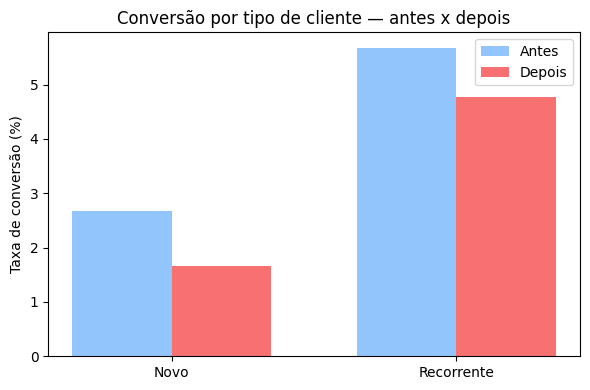

In [13]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(tipos))
largura = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - largura/2, resultado_tipo["conversao_antes"] * 100, largura, label="Antes", color="#93c5fd")
ax.bar(x + largura/2, resultado_tipo["conversao_depois"] * 100, largura, label="Depois", color="#f87171")
ax.set_xticks(x)
ax.set_xticklabels(["Novo", "Recorrente"])
ax.set_ylabel("Taxa de conversão (%)")
ax.set_title("Conversão por tipo de cliente — antes x depois")
ax.legend()
plt.tight_layout()
plt.show()

**Leitura do resultado:** os dois segmentos podem aparecer como estatisticamente significativos (mesma lógica das seções 4 e 5 — base grande), mas olhando a **variação relativa** um segmento cai bem mais que o outro — normalmente `novo`, com queda proporcional bem maior que `recorrente`. A tabela de participação reforça isso: a fatia de pedidos vinda de clientes novos encolhe do período `antes` pro `depois`, exatamente o que se espera se a conversão de quem compra pela primeira vez despencou mais que a de quem já é cliente. O teste de ticket médio, sem diferença significativa entre os dois grupos, mostra que o problema é **taxa de conversão** do cliente novo, não quanto ele gasta quando de fato compra.

**Decisão de negócio:** uma queda concentrada em clientes novos, combinada com os achados de canal (seção 4) e conversão por mês (seção 3), costuma apontar pra um problema específico no funil de **primeira compra** daquele canal/período — cadastro, verificação, meio de pagamento na primeira transação. Vale comparar o funil de checkout de novo x recorrente no canal identificado antes de escalar pra outras hipóteses.

## Síntese — o que a investigação encontrou

| Pergunta | Achado | Teste usado | Ação recomendada |
|---|---|---|---|
| Pedidos ou ticket? | Pedidos pesam mais (~60% da queda), mas ticket médio também caiu de forma real | Decomposição + teste Z de proporção + t de Welch | Focar em conversão, sem descartar o ticket — ver achado da categoria |
| Categorias | Queda concentrada em 1 categoria (que também é a de ticket mais alto, explicando o achado acima) | Contribuição por categoria + qui-quadrado de mix | Checar estoque/fornecedor da categoria identificada |
| Conversão ao longo do tempo | Queda de patamar a partir de um mês específico, não erosão lenta | Regressão de tendência + teste Z antes x depois | Cruzar o mês de início com mudanças de produto/marketing daquele período |
| Canais | Os 3 canais caem, mas 1 deles cai bem mais que os outros dois em magnitude | Teste Z por canal + correção FDR | Priorizar logs/estabilidade técnica do canal com maior queda relativa |
| Regiões | Queda de receita e de conversão desproporcionalmente maiores em 1 região | Contribuição por região + teste Z por região + correção FDR | Checar frete/logística/concorrência local da região identificada |
| Novos x recorrentes | Os 2 segmentos caem, mas clientes novos caem bem mais que recorrentes | Teste Z por segmento + correção FDR + t de Welch (ticket) | Revisar funil de primeira compra no canal/período identificados |

**Como ler a tabela junto:** cada linha isolada já é útil, mas o valor real está na interseção — se os achados de canal, região e segmento apontarem consistentemente pro mesmo subconjunto de clientes (ex: "clientes novos, via App, do Nordeste"), a causa provável é uma só, e vale investigar o cruzamento direto desse subconjunto antes de tratar cada dimensão separadamente. Se os achados apontarem pra subconjuntos diferentes e não sobrepostos, é mais provável que sejam causas independentes acontecendo ao mesmo tempo, cada uma pedindo sua própria correção.